In [1]:
#!pip install numpy pandas matplotlib seaborn scikit-learn

/Users/someshpadiyar/Desktop/Projects/Music_Genre_Classification/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


--- TASK 4: Downstream MLP Classifier on Pre-Extracted Embeddings ---
✅ Embeddings found! Skipping extraction step.

Loading MERT embeddings directly into memory...
Dataset shape: Train (799, 768), Test (200, 768)
Training small MLP Classifier (2 fully connected layers)...

TASK 4 CLASSIFICATION METRICS
Classification Accuracy : 0.7850
Macro F1-score          : 0.7841
----------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.93      0.70      0.80        20
   classical       0.95      1.00      0.98        20
     country       0.59      0.80      0.68        20
       disco       0.67      0.60      0.63        20
      hiphop       0.75      0.90      0.82        20
        jazz       0.95      1.00      0.98        20
       metal       0.95      0.90      0.92        20
         pop       0.70      0.70      0.70        20
      reggae       0.80      0.60      0.69        20
        rock   

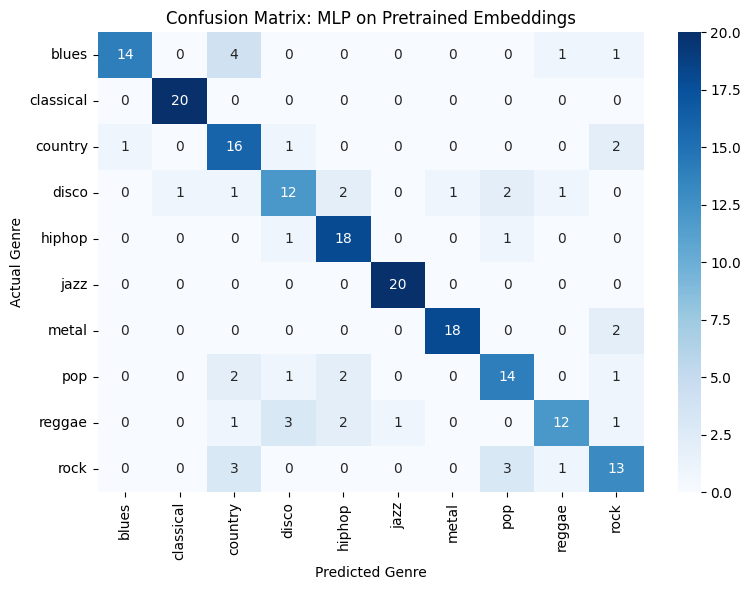


Saving the MERT pipeline for Streamlit...
MERT Model, Scaler, and Label Encoder successfully saved!


In [2]:
import os
import torch
import librosa
from transformers import Wav2Vec2FeatureExtractor, AutoModel
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
import joblib
warnings.filterwarnings('ignore')

print("--- TASK 4: Downstream MLP Classifier on Pre-Extracted Embeddings ---")

embeddings_file = "mert_embeddings_95M.npy"
labels_file = "mert_labels_95M.npy"
song_ids_file = "mert_song_ids_95M.npy"

embeddings_file = "mert_embeddings_95M.npy"
labels_file = "mert_labels_95M.npy"
song_ids_file = "mert_song_ids_95M.npy"

# ==========================================
# NEW: Check & Extract Embeddings if missing
# ==========================================
if not (os.path.exists(embeddings_file) and os.path.exists(labels_file) and os.path.exists(song_ids_file)):
    print("⚠️ Embeddings not found! Starting extraction process from raw audio...")
    
    DATASET_PATH = "./genres_original" 
    MODEL_ID = "m-a-p/MERT-v1-95M"
    TARGET_SR = 24000
    
    processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_ID, trust_remote_code=True)
    model = AutoModel.from_pretrained(MODEL_ID, trust_remote_code=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    embeddings, labels, song_ids = [], [], []
    
    for genre in os.listdir(DATASET_PATH):
        genre_dir = os.path.join(DATASET_PATH, genre)
        if not os.path.isdir(genre_dir): continue
            
        for filename in tqdm(os.listdir(genre_dir), desc=f"Processing {genre}"):
            if not filename.endswith('.wav'): continue
            file_path = os.path.join(genre_dir, filename)
            try:
                audio_array, _ = librosa.load(file_path, sr=TARGET_SR)
                inputs = processor(audio_array, sampling_rate=TARGET_SR, return_tensors="pt")
                inputs = {k: v.to(device) for k, v in inputs.items()}
                with torch.no_grad():
                    outputs = model(**inputs)
                song_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
                embeddings.append(song_embedding)
                labels.append(genre)
                song_ids.append(filename) 
            except Exception as e:
                print(f"Error processing {filename}: {e}")
                
    print("Saving extracted features...")
    np.save(embeddings_file, np.array(embeddings))
    np.save(labels_file, np.array(labels))
    np.save(song_ids_file, np.array(song_ids))
    print("✅ Extraction complete!\n")
else:
    print("✅ Embeddings found! Skipping extraction step.\n")

# ==========================================
# 1. Load Pre-Extracted Data
# ==========================================
print("Loading MERT embeddings directly into memory...")

X = np.load(embeddings_file)
y_text = np.load(labels_file)
song_ids = np.load(song_ids_file)   

# ==========================================
# 2. Strict & Stratified Song-Level Split 
# ==========================================
unique_songs = np.unique(song_ids)

# Map each unique song to its actual genre label for stratification
unique_song_labels = [y_text[np.where(song_ids == song)[0][0]] for song in unique_songs]

train_songs, test_songs = train_test_split(
    unique_songs, 
    test_size=0.2, 
    random_state=42,
    stratify=unique_song_labels
)

# Create masks to reliably filter the data arrays
train_mask = np.isin(song_ids, train_songs)
test_mask = np.isin(song_ids, test_songs)

X_train, X_test = X[train_mask], X[test_mask]
y_train_text, y_test_text = y_text[train_mask], y_text[test_mask]

# Encode text labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_text)
y_test = le.transform(y_test_text)

# ==========================================
# 3. Feature Scaling & MLP Training
# ==========================================
print(f"Dataset shape: Train {X_train.shape}, Test {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training small MLP Classifier (2 fully connected layers)...")
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(256, 128), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    early_stopping=True,     
    n_iter_no_change=10,     
    random_state=42
)

mlp_classifier.fit(X_train_scaled, y_train)
y_pred = mlp_classifier.predict(X_test_scaled)

# ==========================================
# 4. Data Visualization & Metrics Logging
# ==========================================
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*40)
print("TASK 4 CLASSIFICATION METRICS")
print("="*40)
print(f"Classification Accuracy : {acc:.4f}")
print(f"Macro F1-score          : {macro_f1:.4f}")
print("-" * 40)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: MLP on Pretrained Embeddings')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.tight_layout()
plt.show()

# ==========================================
# 5. Save the MERT Pipeline
# ==========================================
print("\nSaving the MERT pipeline for Streamlit...")

# Save the sklearn MLP Model
joblib.dump(mlp_classifier, 'mert_mlp_model.pkl')

# Save the Scaler
joblib.dump(scaler, 'mert_scaler.pkl')

# Save the Label Encoder
joblib.dump(le, 'mert_label_encoder.pkl')

print("MERT Model, Scaler, and Label Encoder successfully saved!")

## YAM-NET

2026-05-04 06:01:14.848826: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-04 06:01:14.848852: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-04 06:01:14.848858: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-04 06:01:14.848879: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 06:01:14.848891: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


=== TASK 4: Pretrained Audio Representation (YAMNet) + MLP Classifier ===

[Phase 1 Skipped] Saved YAMNet embeddings found on disk.

[Phase 2] Loading data and performing strict song-level split...
Dataset shape: Train (799, 1024), Test (200, 1024)

[Phase 3] Building and Training the MLP Classifier...
Epoch 1/100


2026-05-04 06:01:15.274742: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


25/25 [==============================] - 1s 18ms/step - loss: 1.3920 - accuracy: 0.5657 - val_loss: 0.7352 - val_accuracy: 0.7950 - lr: 0.0010
Epoch 2/100
 9/25 [=========>....................] - ETA: 0s - loss: 0.6603 - accuracy: 0.7917

2026-05-04 06:01:15.978874: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


25/25 [==============================] - 0s 8ms/step - loss: 0.6710 - accuracy: 0.7910 - val_loss: 0.5719 - val_accuracy: 0.7950 - lr: 0.0010
Epoch 3/100
25/25 [==============================] - 0s 8ms/step - loss: 0.6619 - accuracy: 0.8023 - val_loss: 0.5018 - val_accuracy: 0.8150 - lr: 0.0010
Epoch 4/100
25/25 [==============================] - 0s 9ms/step - loss: 0.6202 - accuracy: 0.8010 - val_loss: 0.4767 - val_accuracy: 0.8300 - lr: 0.0010
Epoch 5/100
25/25 [==============================] - 0s 7ms/step - loss: 0.5413 - accuracy: 0.8148 - val_loss: 0.4619 - val_accuracy: 0.8300 - lr: 0.0010
Epoch 6/100
25/25 [==============================] - 0s 8ms/step - loss: 0.5263 - accuracy: 0.8273 - val_loss: 0.4694 - val_accuracy: 0.8600 - lr: 0.0010
Epoch 7/100
25/25 [==============================] - 0s 7ms/step - loss: 0.4543 - accuracy: 0.8623 - val_loss: 0.4578 - val_accuracy: 0.8550 - lr: 0.0010
Epoch 8/100
25/25 [==============================] - 0s 8ms/step - loss: 0.4956 - accura

2026-05-04 06:01:22.338961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


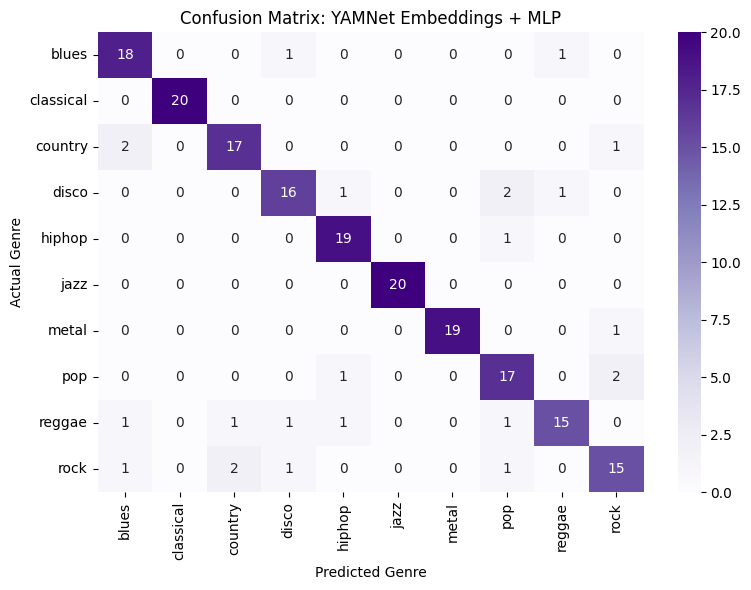

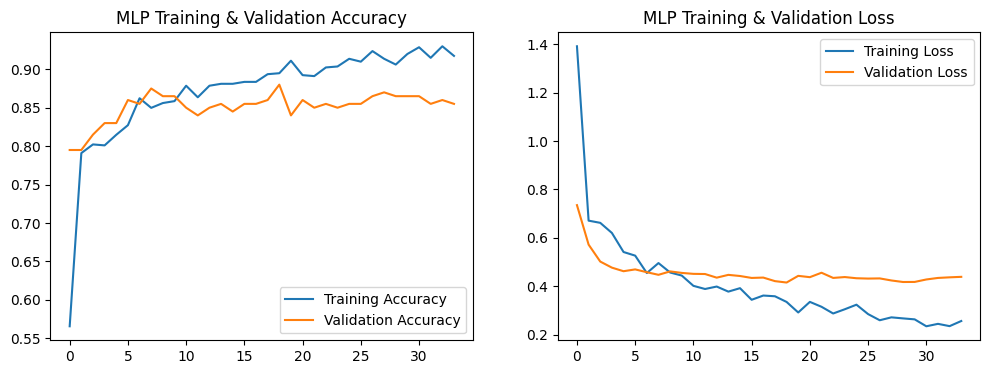


[Phase 5] Saving the pipeline for future inference...
Success! Model, Scaler, and Label Encoder are saved to your disk.


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
import joblib
warnings.filterwarnings('ignore')

print("=== TASK 4: Pretrained Audio Representation (YAMNet) + MLP Classifier ===")

# ==============================================================================
# SECTION 1: YAMNet Feature Extraction (Run Once)
# ==============================================================================
# IMPORTANT: Update this path to your actual raw audio folder!
audio_dir = 'Data/genres_original'

embeddings_file = "yamnet_embeddings.npy"
labels_file = "yamnet_labels.npy"
song_ids_file = "yamnet_song_ids.npy"

# Only run extraction if the files don't already exist
if not (os.path.exists(embeddings_file) and os.path.exists(labels_file)):
    print("\n[Phase 1] Extracting YAMNet Embeddings from raw audio. This may take a few minutes...")
    
    # Load YAMNet from TensorFlow Hub
    yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
    
    embeddings_list = []
    labels_list = []
    song_ids_list = []
    
    # Iterate through genre folders
    for genre in os.listdir(audio_dir):
        genre_path = os.path.join(audio_dir, genre)
        if not os.path.isdir(genre_path):
            continue
            
        print(f"Processing genre: {genre}...")
        for filename in os.listdir(genre_path):
            if filename.endswith('.wav'):
                file_path = os.path.join(genre_path, filename)
                
                try:
                    # YAMNet requires exactly 16kHz mono audio
                    wav, sr = librosa.load(file_path, sr=16000, mono=True)
                    waveform = tf.convert_to_tensor(wav, dtype=tf.float32)
                    
                    # Extract features
                    _, yamnet_embs, _ = yamnet_model(waveform)
                    
                    # Average the time-steps into ONE 1024-D vector per song
                    song_embedding = tf.reduce_mean(yamnet_embs, axis=0).numpy()
                    
                    embeddings_list.append(song_embedding)
                    labels_list.append(genre)
                    
                    # Extract song ID (e.g., "blues.00000.wav" -> "blues.00000")
                    parts = filename.split('.')
                    song_ids_list.append(f"{parts[0]}.{parts[1]}")
                    
                except Exception as e:
                    print(f"  -> Error processing {filename}: {e}")

    # Save to disk for future runs
    np.save(embeddings_file, np.array(embeddings_list))
    np.save(labels_file, np.array(labels_list))
    np.save(song_ids_file, np.array(song_ids_list))
    print("[Phase 1 Complete] YAMNet features saved to disk.\n")
else:
    print("\n[Phase 1 Skipped] Saved YAMNet embeddings found on disk.\n")


# ==============================================================================
# SECTION 2: Data Loading & Stratified Song-Level Split
# ==============================================================================
print("[Phase 2] Loading data and performing strict song-level split...")

X = np.load(embeddings_file)
y_text = np.load(labels_file)
song_ids = np.load(song_ids_file)

# Encode text labels into integers
le = LabelEncoder()
y_encoded = le.fit_transform(y_text)
num_classes = len(le.classes_)

unique_songs = np.unique(song_ids)

# Map each unique song to its actual genre label for stratification
unique_song_labels = [y_encoded[np.where(song_ids == song)[0][0]] for song in unique_songs]

# 80/20 Train-Test Split at the SONG level
train_songs, test_songs = train_test_split(
    unique_songs, 
    test_size=0.2, 
    random_state=42,
    stratify=unique_song_labels
)

# Create masks to filter the data arrays
train_mask = np.isin(song_ids, train_songs)
test_mask = np.isin(song_ids, test_songs)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y_encoded[train_mask], y_encoded[test_mask]

# Scale the embeddings (Crucial for deep learning stability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset shape: Train {X_train_scaled.shape}, Test {X_test_scaled.shape}")


# ==============================================================================
# SECTION 3: The "Shallow & Strict" MLP Classifier
# ==============================================================================
print("\n[Phase 3] Building and Training the MLP Classifier...")

# YAMNet always outputs a 1024-dimensional embedding
EMBEDDING_DIM = X_train_scaled.shape[1] 

classifier = models.Sequential([
    layers.InputLayer(input_shape=(EMBEDDING_DIM,)),
    
    # Standardize the inputs
    layers.BatchNormalization(),
    
    # Hidden Layer 1: Wide enough to catch patterns, strict enough to not memorize
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5), # 50% Dropout is crucial here
    
    # Hidden Layer 2: Narrowing down to the classes
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping is mandatory because embeddings learn extremely fast
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=15, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5,
    verbose=1
)

# Train the model
history = classifier.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100, # Set high, Early Stopping will halt it at the peak
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)


# ==============================================================================
# SECTION 4: Evaluation and Visualization
# ==============================================================================
print("\n[Phase 4] Generating Final Evaluation Metrics...")

# Predict on test set
y_pred_probs = classifier.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*40)
print("TASK 4 YAMNet CLASSIFICATION METRICS")
print("="*40)
print(f"Classification Accuracy : {acc:.4f}")
print(f"Macro F1-score          : {macro_f1:.4f}")
print("-" * 40)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: YAMNet Embeddings + MLP')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.tight_layout()
plt.show()

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MLP Training & Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Training & Validation Loss')
plt.legend()
plt.show()

# ==============================================================================
# SECTION 5: Save Model and Preprocessors
# ==============================================================================
print("\n[Phase 5] Saving the pipeline for future inference...")

# 1. Save the Keras Model (Using the modern .keras format)
classifier.save('yamnet_music_model.keras')

# 2. Save the Scaler
joblib.dump(scaler, 'yamnet_scaler.pkl')

# 3. Save the Label Encoder
joblib.dump(le, 'yamnet_label_encoder.pkl')

print("Success! Model, Scaler, and Label Encoder are saved to your disk.")